In [1]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union
import osmnx as ox
import warnings
warnings.filterwarnings('ignore')

In [2]:
ox.settings.overpass_url = 'https://overpass.private.coffee/api/interpreter'
ox.settings.requests_timeout = 600

In [7]:
# Словарь якорных объектов с OSM-тегами
ANCHOR_TAGS = {
    # Транспортные узлы
    'railway_station': {'railway': 'station'},
    'bus_station': {'amenity': 'bus_station'},
    
    # Образование (крупные)
    'university': {'amenity': 'university'},
    'college': {'amenity': 'college'},
    
    # Здравоохранение (крупные)
    'hospital': {'amenity': 'hospital'},
    
    # Торговля (крупные)
    'mall': {'shop': 'mall'},
    'department_store': {'shop': 'department_store'},
    'supermarket': {'shop': 'supermarket'},
    
    # Деловые объекты
    'business_centre': {'office': 'government'},
    'offices': {'building': 'office'},
    
    # Культура и спорт
    'stadium': {'leisure': 'stadium'},
    'theatre': {'amenity': 'theatre'},
    'cinema': {'amenity': 'cinema'},
    
    # Административные
    'townhall': {'amenity': 'townhall'},
    'courthouse': {'amenity': 'courthouse'},
}

In [8]:
routes = gpd.read_file(r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\routes\yandex_izhevsk_28409.gpkg", layer='yandex_routes').to_crs(epsg=4326)
stops = gpd.read_file(r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\routes\yandex_izhevsk_28409.gpkg", layer='yandex_stops').to_crs(epsg=4326)
isochrones = gpd.read_file(r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\isochrones_result.gpkg").to_crs(epsg=4326)

In [ ]:
def get_anchor_pois_from_osm(isochrones_gdf, anchor_tags=ANCHOR_TAGS):
    """
    Получение якорных POI из OSM в пределах изохрон
    """
    # Объединяем все изохроны в одну область поиска
    search_area = unary_union(isochrones_gdf.geometry)
    
    # Получаем bbox для запроса
    minx, miny, maxx, maxy = search_area.bounds
    
    all_pois = []
    
    print("Загрузка якорных объектов из OSM...")
    
    for anchor_type, tags in anchor_tags.items():
        try:
            # Получаем POI по тегам
            pois = ox.features_from_bbox(
                bbox=(maxy, miny, maxx, minx),  # north, south, east, west
                tags=tags
            )
            
            if len(pois) > 0:
                pois = pois.reset_index()
                pois['anchor_type'] = anchor_type
                
                # Преобразуем полигоны в центроиды для единообразия
                pois['geometry'] = pois.geometry.centroid
                
                # Оставляем только точки внутри изохрон
                pois_gdf = gpd.GeoDataFrame(pois, crs='EPSG:4326')
                pois_in_area = gpd.sjoin(
                    pois_gdf, 
                    isochrones_gdf[['geometry']], 
                    predicate='within'
                )
                
                if len(pois_in_area) > 0:
                    all_pois.append(pois_in_area)
                    print(f"  ✓ {anchor_type}: найдено {len(pois_in_area)} объектов")
                    
        except Exception as e:
            print(f"  ✗ {anchor_type}: ошибка - {str(e)[:50]}")
            continue
    
    if all_pois:
        result = pd.concat(all_pois, ignore_index=True)
        # Удаляем дубликаты (объект может попасть в несколько изохрон)
        result = result.drop_duplicates(subset=['osmid'], keep='first')
        return gpd.GeoDataFrame(result, crs='EPSG:4326')
    else:
        return gpd.GeoDataFrame()

# Получаем якорные объекты
anchor_pois = get_anchor_pois_from_osm(isochrones, ANCHOR_TAGS)
print(f"\nВсего уникальных якорных объектов: {len(anchor_pois)}")

Загрузка якорных объектов из OSM...
  ✓ railway_station: найдено 14 объектов


C:\Users\WSY\AppData\Local\Temp\ipykernel_7012\427229683.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois['geometry'] = pois.geometry.centroid


  ✗ bus_station: ошибка - 'overpass.private.coffee' responded: 200 OK <?xml 
  ✗ university: ошибка - 'overpass.private.coffee' responded: 502 Bad Gatew


C:\Users\WSY\AppData\Local\Temp\ipykernel_7012\427229683.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois['geometry'] = pois.geometry.centroid


  ✓ college: найдено 124 объектов
  ✗ hospital: ошибка - 'overpass.private.coffee' responded: 200 OK <?xml 


C:\Users\WSY\AppData\Local\Temp\ipykernel_7012\427229683.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois['geometry'] = pois.geometry.centroid


  ✓ mall: найдено 607 объектов


In [7]:
def calculate_route_length(stops_gdf=None, route_gdf=None):
    """
    Расчёт длины маршрута
    
    Если есть линия маршрута - используем её
    Если нет - строим по остановкам
    """
    if route_gdf is not None:
        # Используем готовую линию маршрута
        route_projected = route_gdf.to_crs(epsg=3857)  # метрическая проекция
        length_m = route_projected.geometry.length.sum()
    else:
        # Строим линию по остановкам
        from shapely.geometry import LineString
        
        # Сортируем остановки по порядку (нужен столбец с порядком!)
        # Если его нет, просто соединяем в текущем порядке
        if 'stop_sequence' in stops_gdf.columns:
            stops_sorted = stops_gdf.sort_values('stop_sequence')
        elif 'order' in stops_gdf.columns:
            stops_sorted = stops_gdf.sort_values('order')
        else:
            stops_sorted = stops_gdf
            print("⚠️ Порядок остановок не определён, используется текущий порядок")
        
        # Создаём линию маршрута
        coords = [(p.x, p.y) for p in stops_sorted.geometry]
        route_line = LineString(coords)
        
        # Проецируем для точного расчёта длины
        route_gdf_temp = gpd.GeoDataFrame(geometry=[route_line], crs='EPSG:4326')
        route_projected = route_gdf_temp.to_crs(epsg=3857)
        length_m = route_projected.geometry.length.sum()
    
    length_km = length_m / 1000
    return length_km

# Расчёт длины
route_length_km = calculate_route_length(stops, routes)
print(f"Длина маршрута: {route_length_km:.2f} км")

Длина маршрута: 3806.44 км


In [8]:
def calculate_anchor_density(anchor_pois, route_length_km, by_category=True):
    """
    Расчёт плотности якорных объектов
    
    Returns:
    --------
    dict с результатами
    """
    N_y = len(anchor_pois)  # Общее число якорных объектов
    L = route_length_km      # Длина маршрута в км
    
    # Плотность якорных объектов (объектов/км)
    d_y = N_y / L if L > 0 else 0
    
    results = {
        'total_anchors': N_y,
        'route_length_km': round(L, 2),
        'anchor_density': round(d_y, 2),
    }
    
    # Разбивка по категориям
    if by_category and 'anchor_type' in anchor_pois.columns:
        category_counts = anchor_pois['anchor_type'].value_counts().to_dict()
        results['by_category'] = category_counts
    
    return results

# === ИТОГОВЫЙ РАСЧЁТ ===
results = calculate_anchor_density(anchor_pois, route_length_km)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ РАСЧЁТА")
print("="*50)
print(f"Количество якорных объектов (N_y): {results['total_anchors']}")
print(f"Длина маршрута (L): {results['route_length_km']} км")
print(f"Плотность якорей (d_y): {results['anchor_density']} объектов/км")
print("\nПо категориям:")
for cat, count in results.get('by_category', {}).items():
    print(f"  • {cat}: {count}")


РЕЗУЛЬТАТЫ РАСЧЁТА
Количество якорных объектов (N_y): 3
Длина маршрута (L): 3806.44 км
Плотность якорей (d_y): 0.0 объектов/км

По категориям:
  • railway_station: 3


C:\Users\WSY\AppData\Local\Temp\ipykernel_7400\1295671641.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left', fontsize=8)


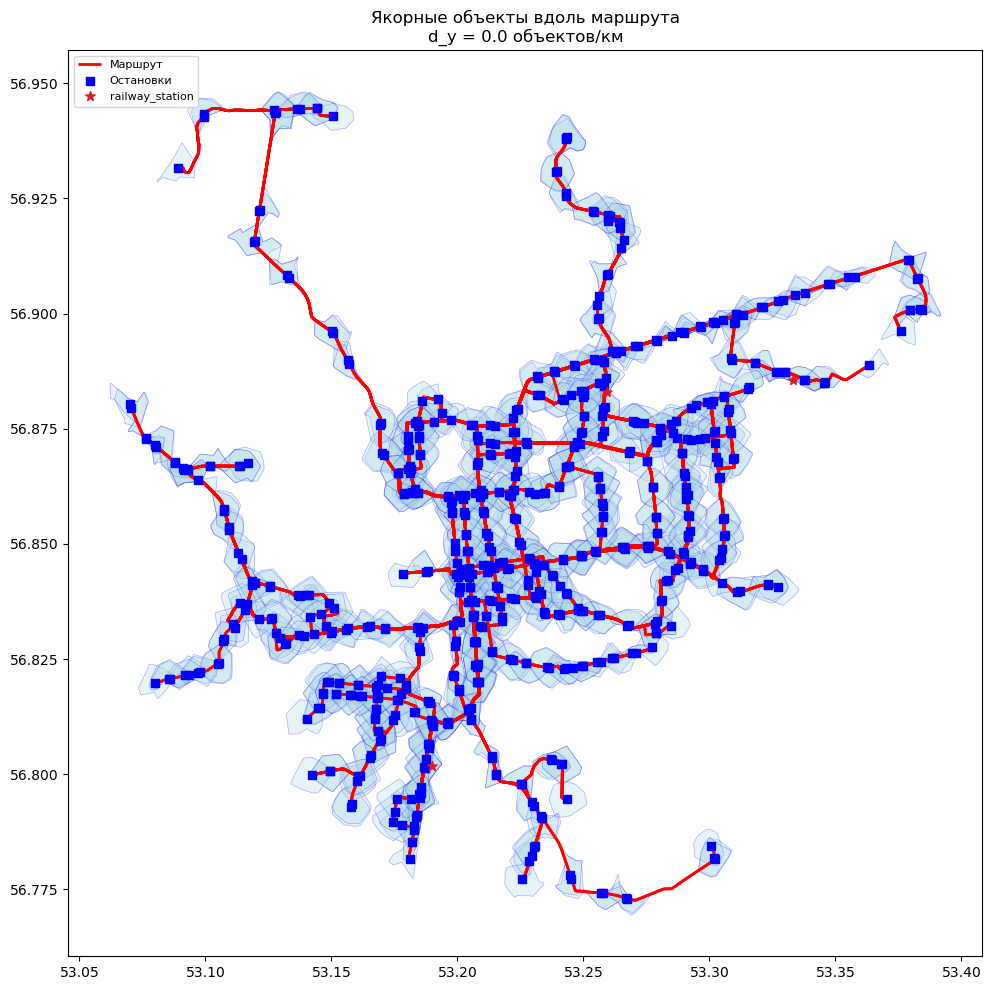

In [10]:
import matplotlib.pyplot as plt

def visualize_anchors(isochrones, stops, anchor_pois, route=None):
    """Визуализация результатов"""
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Изохроны
    isochrones.plot(ax=ax, alpha=0.3, color='lightblue', 
                    edgecolor='blue', linewidth=0.5, label='Изохроны 500м')
    
    # Маршрут (если есть)
    if route is not None:
        route.plot(ax=ax, color='red', linewidth=2, label='Маршрут')
    
    # Остановки
    stops.plot(ax=ax, color='blue', markersize=30, 
               marker='s', label='Остановки', zorder=3)
    
    # Якорные объекты по категориям
    if len(anchor_pois) > 0:
        categories = anchor_pois['anchor_type'].unique()
        colors = plt.cm.Set1(range(len(categories)))
        
        for cat, color in zip(categories, colors):
            mask = anchor_pois['anchor_type'] == cat
            anchor_pois[mask].plot(ax=ax, color=color, markersize=50,
                                   marker='*', label=cat, zorder=4)
    
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title(f'Якорные объекты вдоль маршрута\n'
                 f'd_y = {results["anchor_density"]} объектов/км')
    
    plt.tight_layout()
    plt.savefig('anchor_density_map.png', dpi=150)
    plt.show()

visualize_anchors(isochrones, stops, anchor_pois, routes)

In [ ]:
# Сохранение якорных объектов в файл
anchor_pois.to_file('anchor_pois.gpkg', driver='GPKG')

# Сохранение статистики
import json
with open('anchor_density_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("\n✓ Результаты сохранены!")